In [2]:
# load packages
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

# Functions

In [3]:
def missing_data(df):
    """Display missing values in a dataset"""

    #total missing 
    total = df.isna().sum().sum()
    print(f"\nThe total amount of missing values in the dataset is {total}.")
    #how many values are missing per column?
    missing = df.isna().sum()
    print(f"\nThe missing values per column in the copy:\n{missing}")

def clean_data(df, clean=True):
    """Displays missing values, number of rows, and columns in a dataset.

    Parameters: 
        clean : boolean (default is True)
        Assumes that user will want to remove any missing values. 
    """
    #print number of rows and columns
    print(f"Number of rows in dataset: {df.shape[0]}")
    print(f"Number of columns in dataset: {df.shape[1]}")
    
    #display missing values
    missing_data(df)
    
    if clean:
        #remove missing values
        clean_data = df.dropna()
        
        #recalculate column and row number
        print(f"Number of rows in dataset after removing missing values: {clean_data.shape[0]}")
        print(f"Number of columns in dataset after removing missing values: {clean_data.shape[1]}")
        
        return clean_data
    else:
        return df

def replace_census_values(df):
    """Replace annotated values appropriately with NAN"""
    df = df.replace('(X)', np.nan)
    df = df.replace('N', np.nan)
    return df

def convert_numeric(x):
    """Convert values in value column to a numeric type"""
    if pd.isna(x):
        return np.nan
    
    x = str(x).strip()
    
    # True missing markers
    missing_markers = {"-", "**", "***", "*****"}
    if x in missing_markers:
        return np.nan
    
    # Remove annotation symbols attached to numbers
    x = x.replace("*", "").replace("+", "")
    
    # Remove commas
    x = x.replace(',', '')

    # Percent
    if '%' in x:
        try:
            return float(x.replace('%','')) / 100
        except:
            return np.nan
    else:
        try:
            return float(x)
        except:
            return np.nan
    

def nested_data(df,label):
    # Identify first level of nested rows: 
    top_level_indices = df[df.loc[:,label].str.isupper()].index
        
    # Create an empty dictionary to store the values of the nested rows
    blocks = {}
        
    # Iterate over the length of the level indices
    for i in range(len(top_level_indices)):
        start = top_level_indices[i]
        end = top_level_indices[i+1] if i+1 < len(top_level_indices) else len(df)
            
        # Block Name is the indice and the associated text value in that column
        block_name = df.loc[start, label]
        blocks[block_name] = df.iloc[start:end].copy()
        blocks[block_name] = reshape(blocks[block_name], label=label)
    return blocks

def reshape(df, label, convert_value=True):
    # Melt dataset
    df = df.melt(
        id_vars=label,
        var_name="state_metric",
        value_name="value")
    
    # Using the headers, create new columns by splitting the header on !!
    max_splits = df["state_metric"].str.count("!!").max() + 1
    split_cols = [f"group_{i+1}" for i in range(max_splits)]
    df[split_cols] = df["state_metric"].str.split("!!", expand=True)
    
    # Reorganize columns
    first_cols = split_cols
    df = df[first_cols + [label, "value", "state_metric"]]
    
    #First column of split_cols is always state, last one is always metric
    # First column is state
    df = df.rename(columns={split_cols[0]: "state"})
    df = df.rename(columns={split_cols[-1]: "metric"})
    
    # Drop all other metrics, keep Percent
    if "Percent" in df["metric"].unique():
        df = df[df["metric"] == "Percent"]
    else:
        df = df[df["metric"] == "Estimate"]

    # Clean column so that next step in dropping executes well
    df[label] = df[label].str.strip()
    
    # Drop the column that contains the previous header names
    df = df.drop(columns="state_metric")
    
    # Apply the convert value function to the value columns only if True (default)
    if convert_value:
        df["value"] = df["value"].apply(convert_numeric)
    else:
        df["value"]

    return df

# Load Census Datasets

## USA by States Datasets

In [4]:
# load income and poverty by states in 2024
income_povertyDF_state = pd.read_csv(r"..\DATA\RAW_CENSUS_DATA\USA_STATES\S1901_income_poverty_2024.csv")

# load education attainment
education_attainmentDF_state = pd.read_csv(r"..\DATA\RAW_CENSUS_DATA\USA_STATES\S1501_educational_attainment_2024.csv")

# load economic characteristics
economic_characterisiticsDF_state = pd.read_csv(r"..\DATA\RAW_CENSUS_DATA\USA_STATES\DP03_economic_characteristics_2024.csv")

# load demographic and housing estimates
demographic_housingDF_state = pd.read_csv(r"..\DATA\RAW_CENSUS_DATA\USA_STATES\DP05_demographic_housing_2024.csv")

## USA by Counties Dataset

In [5]:
# load income and poverty by states in 2024
income_povertyDF_county = pd.read_csv(r"..\DATA\RAW_CENSUS_DATA\USA_COUNTY\S1901_income_poverty_2024_county.csv")

# load education attainment
education_attainmentDF_county = pd.read_csv(r"..\DATA\RAW_CENSUS_DATA\USA_COUNTY\S1501_educational_attainment_2024_county.csv")

# load economic characteristics
economic_characterisiticsDF_county = pd.read_csv(r"..\DATA\RAW_CENSUS_DATA\USA_COUNTY\DP03_economic_characteristics_2024_county.csv")

# load demographic and housing estimates
demographic_housingDF_county = pd.read_csv(r"..\DATA\RAW_CENSUS_DATA\USA_COUNTY\DP05_demographic_housing_2024_county.csv")

# Restructuring Datasets

## US Datasets

### Income_Poverty Dataset

#### View Source Table

In [6]:
income_povertyDF_state.head(20)

,Label (Grouping),Alabama!!Households!!Estimate,Alabama!!Households!!Margin of Error,Alabama!!Families!!Estimate,Alabama!!Families!!Margin of Error,Alabama!!Married-couple families!!Estimate,Alabama!!Married-couple families!!Margin of Error,Alabama!!Nonfamily households!!Estimate,Alabama!!Nonfamily households!!Margin of Error,Alaska!!Households!!Estimate,...,Wyoming!!Nonfamily households!!Estimate,Wyoming!!Nonfamily households!!Margin of Error,Puerto Rico!!Households!!Estimate,Puerto Rico!!Households!!Margin of Error,Puerto Rico!!Families!!Estimate,Puerto Rico!!Families!!Margin of Error,Puerto Rico!!Married-couple families!!Estimate,Puerto Rico!!Married-couple families!!Margin of Error,Puerto Rico!!Nonfamily households!!Estimate,Puerto Rico!!Nonfamily households!!Margin of Error
0,Total,"2,059,528","±11,700","1,328,397","±15,669","945,230","±13,945","731,131","±12,070","274,045",...,"96,166","±4,034","1,242,609","±10,856","764,486","±11,451","419,876","±8,970","478,123","±10,310"
1,"Less than $10,000",6.4%,±0.3,3.7%,±0.3,1.3%,±0.2,12.2%,±0.8,3.7%,...,10.1%,±1.9,18.3%,±0.6,12.3%,±0.7,5.2%,±0.6,29.5%,±1.1
2,"$10,000 to $14,999",4.7%,±0.3,2.2%,±0.2,0.9%,±0.1,9.5%,±0.6,2.0%,...,4.8%,±1.2,11.0%,±0.5,7.7%,±0.5,6.2%,±0.7,17.0%,±0.9
3,"$15,000 to $24,999",7.8%,±0.3,5.1%,±0.4,2.5%,±0.3,13.3%,±0.7,5.2%,...,12.0%,±1.9,17.9%,±0.6,17.1%,±0.8,14.3%,±0.8,20.4%,±1.0
4,"$25,000 to $34,999",7.9%,±0.3,5.8%,±0.4,4.0%,±0.3,11.9%,±0.7,4.9%,...,12.3%,±1.9,12.1%,±0.6,13.1%,±0.6,12.9%,±0.8,10.5%,±1.0
5,"$35,000 to $49,999",11.2%,±0.4,10.0%,±0.4,7.2%,±0.4,14.2%,±0.7,8.8%,...,16.2%,±2.1,13.4%,±0.6,15.8%,±0.8,16.3%,±1.0,9.1%,±0.9
6,"$50,000 to $74,999",16.8%,±0.5,16.5%,±0.5,15.5%,±0.6,17.3%,±0.8,14.6%,...,19.2%,±2.4,12.6%,±0.5,15.5%,±0.8,18.2%,±1.1,6.9%,±0.6
7,"$75,000 to $99,999",13.3%,±0.4,14.9%,±0.5,15.8%,±0.6,9.5%,±0.7,12.8%,...,7.9%,±1.4,6.4%,±0.4,7.7%,±0.5,10.6%,±0.8,3.2%,±0.5
8,"$100,000 to $149,999",16.0%,±0.4,20.2%,±0.6,24.5%,±0.7,7.4%,±0.6,20.6%,...,9.7%,±1.6,4.8%,±0.4,6.0%,±0.5,8.8%,±0.8,2.2%,±0.4
9,"$150,000 to $199,999",7.5%,±0.3,10.0%,±0.4,12.9%,±0.6,2.6%,±0.4,12.7%,...,4.2%,±1.3,1.9%,±0.2,2.4%,±0.3,3.7%,±0.5,0.7%,±0.2


#### Reformatting Table

In [7]:
# Create a copy just in case 
df = income_povertyDF_state.copy()

# Choose new label name
label="income"

# First replace any (X) ie NAN values with np.nan by calling
df = replace_census_values(df)
    
# Rename first column to label: education
df = df.rename(columns={df.columns[0]:label})

# Split Blocks if neccessary

# Otherwise just reshape
df = reshape(df,label=label)

# View Blocks of data
df.head(20)

,state,group_2,metric,income,value
0,Alabama,Households,Estimate,Total,2059528.000
1,Alabama,Households,Estimate,"Less than $10,000",0.064
2,Alabama,Households,Estimate,"$10,000 to $14,999",0.047
3,Alabama,Households,Estimate,"$15,000 to $24,999",0.078
4,Alabama,Households,Estimate,"$25,000 to $34,999",0.079
5,Alabama,Households,Estimate,"$35,000 to $49,999",0.112
6,Alabama,Households,Estimate,"$50,000 to $74,999",0.168
7,Alabama,Households,Estimate,"$75,000 to $99,999",0.133
8,Alabama,Households,Estimate,"$100,000 to $149,999",0.160
9,Alabama,Households,Estimate,"$150,000 to $199,999",0.075


#### Creating income dataframe

In [8]:
# I only need household group 
income = df[df["group_2"] == "Households"]

# I only household income values for each state. The above dataset is highly nested. For each state, I need "in labor" and "not in labor" specifically from emplyment status grouping. 

income_filtered = income.loc[income["income"].isin(["Total", 
                                                    "Less than $10,000",
                                                    "$10,000 to $14,999",
                                                    "$15,000 to $24,999",
                                                    "$25,000 to $34,999",
                                                    "$35,000 to $49,999",
                                                    "$50,000 to $74,999",
                                                    "$75,000 to $99,999",
                                                    "$100,000 to $149,999",
                                                    "$150,000 to $199,999",
                                                    "$200,000 or more"])]

# remove metric column 
income_filtered = income_filtered.drop(columns=["metric","group_2"])

# The employment status group has two "in labor force" one is specifically for females. Since drop duplicates always keeps the first one, I use it. 
income_filtered = income_filtered.drop_duplicates(subset=["state","income"], keep="first")

# Now pivot table 
income_df = income_filtered.pivot_table(
    index = "state",
    columns = "income",
    values = "value"
).reset_index()

# Reorder columns 
income_df = income_df[["state","Less than $10,000",
                        "$10,000 to $14,999",
                        "$15,000 to $24,999",
                        "$25,000 to $34,999",
                        "$35,000 to $49,999",
                        "$50,000 to $74,999",
                        "$75,000 to $99,999",
                        "$100,000 to $149,999",
                        "$150,000 to $199,999",
                        "$200,000 or more","Total"]]

# View 
income_df

income,state,"Less than $10,000","$10,000 to $14,999","$15,000 to $24,999","$25,000 to $34,999","$35,000 to $49,999","$50,000 to $74,999","$75,000 to $99,999","$100,000 to $149,999","$150,000 to $199,999","$200,000 or more",Total
0,Alabama,0.064,0.047,0.078,0.079,0.112,0.168,0.133,0.160,0.075,0.083,2059528.0
1,Alaska,0.037,0.020,0.052,0.049,0.088,0.146,0.128,0.206,0.127,0.146,274045.0
2,Arizona,0.049,0.025,0.056,0.061,0.104,0.164,0.139,0.183,0.098,0.122,2982475.0
3,Arkansas,0.060,0.046,0.082,0.090,0.128,0.176,0.128,0.158,0.066,0.066,1246754.0
4,California,0.046,0.030,0.050,0.049,0.079,0.131,0.114,0.179,0.112,0.210,13797638.0
5,Colorado,0.043,0.023,0.046,0.049,0.078,0.147,0.128,0.190,0.118,0.179,2479892.0
6,Connecticut,0.048,0.030,0.050,0.050,0.085,0.138,0.117,0.173,0.116,0.194,1455235.0
7,Delaware,0.049,0.023,0.046,0.050,0.101,0.156,0.144,0.193,0.108,0.129,412304.0
8,District of Columbia,0.078,0.035,0.057,0.039,0.053,0.105,0.098,0.168,0.101,0.266,329687.0
9,Florida,0.052,0.031,0.061,0.067,0.106,0.167,0.132,0.177,0.089,0.119,9141675.0


#### Save dataframe in csv

In [9]:
income_df.to_csv("../DATA/PROCESSED_CENSUS_DATA/US_census_income_2024.csv")

### Educational_Attainment

#### View Source Table

In [10]:
# View Data
education_attainmentDF_state.head(20)

,Label (Grouping),Alabama!!Total!!Estimate,Alabama!!Total!!Margin of Error,Alabama!!Percent!!Estimate,Alabama!!Percent!!Margin of Error,Alabama!!Male!!Estimate,Alabama!!Male!!Margin of Error,Alabama!!Percent Male!!Estimate,Alabama!!Percent Male!!Margin of Error,Alabama!!Female!!Estimate,...,Puerto Rico!!Percent!!Estimate,Puerto Rico!!Percent!!Margin of Error,Puerto Rico!!Male!!Estimate,Puerto Rico!!Male!!Margin of Error,Puerto Rico!!Percent Male!!Estimate,Puerto Rico!!Percent Male!!Margin of Error,Puerto Rico!!Female!!Estimate,Puerto Rico!!Female!!Margin of Error,Puerto Rico!!Percent Female!!Estimate,Puerto Rico!!Percent Female!!Margin of Error
0,AGE BY EDUCATIONAL ATTAINMENT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Population 18 to 24 years,"485,435","±6,891",(X),(X),"240,460","±4,132",(X),(X),"244,975",...,(X),(X),"147,489","±2,687",(X),(X),"147,015","±2,514",(X),(X)
2,Less than high school graduate,"56,245","±4,338",11.6%,±0.9,"34,043","±3,757",14.2%,±1.5,"22,202",...,6.9%,±1.0,"12,769","±2,189",8.7%,±1.5,"7,570","±1,970",5.1%,±1.3
3,High school graduate (includes equival...,"180,682","±9,199",37.2%,±1.7,"97,301","±6,433",40.5%,±2.5,"83,381",...,30.1%,±2.0,"52,251","±4,376",35.4%,±3.0,"36,402","±3,434",24.8%,±2.3
4,Some college or associate's degree,"201,084","±8,807",41.4%,±1.8,"90,341","±5,670",37.6%,±2.4,"110,743",...,52.5%,±2.2,"72,132","±4,906",48.9%,±3.0,"82,369","±3,908",56.0%,±2.5
5,Bachelor's degree or higher,"47,424","±4,312",9.8%,±0.9,"18,775","±2,881",7.8%,±1.2,"28,649",...,10.5%,±1.4,"10,337","±2,502",7.0%,±1.7,"20,674","±3,203",14.1%,±2.2
6,Population 25 years and over,"3,540,061","±7,505",(X),(X),"1,678,118","±5,233",(X),(X),"1,861,943",...,(X),(X),"1,119,700","±2,685",(X),(X),"1,308,365","±2,515",(X),(X)
7,Less than 9th grade,"124,848","±8,256",3.5%,±0.2,"65,301","±5,378",3.9%,±0.3,"59,547",...,11.1%,±0.4,"136,357","±6,620",12.2%,±0.6,"132,397","±7,467",10.1%,±0.6
8,"9th to 12th grade, no diploma","245,087","±8,905",6.9%,±0.3,"132,063","±6,684",7.9%,±0.4,"113,024",...,7.0%,±0.3,"89,345","±6,005",8.0%,±0.5,"81,118","±4,762",6.2%,±0.4
9,High school graduate (includes equival...,"1,058,670","±14,946",29.9%,±0.4,"536,107","±10,847",31.9%,±0.7,"522,563",...,27.8%,±0.7,"350,753","±12,188",31.3%,±1.1,"325,179","±9,299",24.9%,±0.7


#### Reformatting Table

In [11]:
# Create a copy just in case 
df = education_attainmentDF_state.copy()

# Choose new label name
label="education"

# First replace any (X) ie NAN values with np.nan by calling
df = replace_census_values(df)
    
# Rename first column to label: education
df = df.rename(columns={df.columns[0]:label})

# Split Blocks
df = nested_data(df,label=label)

# View Blocks of data
print(f"Category Groups in {label} dataset:")
for x in df.keys():
    print(f"-{x}")

df["AGE BY EDUCATIONAL ATTAINMENT"].head(20)

Category Groups in education dataset:
-AGE BY EDUCATIONAL ATTAINMENT
-RACE AND HISPANIC OR LATINO ORIGIN BY EDUCATIONAL ATTAINMENT
-POVERTY RATE FOR THE POPULATION 25 YEARS AND OVER FOR WHOM POVERTY STATUS IS DETERMINED BY EDUCATIONAL ATTAINMENT LEVEL
-MEDIAN EARNINGS IN THE PAST 12 MONTHS (IN 2024 INFLATION-ADJUSTED DOLLARS)


,state,group_2,metric,education,value
0,Alabama,Total,Estimate,AGE BY EDUCATIONAL ATTAINMENT,NaN
1,Alabama,Total,Estimate,Population 18 to 24 years,485435.0
2,Alabama,Total,Estimate,Less than high school graduate,56245.0
3,Alabama,Total,Estimate,High school graduate (includes equivalency),180682.0
4,Alabama,Total,Estimate,Some college or associate's degree,201084.0
5,Alabama,Total,Estimate,Bachelor's degree or higher,47424.0
6,Alabama,Total,Estimate,Population 25 years and over,3540061.0
7,Alabama,Total,Estimate,Less than 9th grade,124848.0
8,Alabama,Total,Estimate,"9th to 12th grade, no diploma",245087.0
9,Alabama,Total,Estimate,High school graduate (includes equivalency),1058670.0


#### Creating education dataset

In [12]:
# Save one of the blocks into its own dataframe
education_df = df["AGE BY EDUCATIONAL ATTAINMENT"]

# Drop the row that has the tabel title in it
education_df = education_df[
    education_df["education"] != "AGE BY EDUCATIONAL ATTAINMENT"
]
# The data is more nested so it needs to be unnested by population groups
education_df['age_group'] = education_df['education'].where(
    education_df['education'].str.contains("Population", na=False)
)

# Need to fowardfill since it place NA
education_df['age_group'] = education_df['age_group'].ffill()

# Now I want to remove the nested labels
education_df = education_df[~education_df['education'].str.contains("Population", na=False)]

# And I only want Percent Estimates
education_df = education_df[education_df["group_2"] == "Percent"]

# Remove the group_2 and metric column
education_df = education_df.drop(columns=["group_2","metric"])

# Reorganize the column, it is expected for the state to appear multiple times
education_df = education_df[["state", "age_group", "education", "value"]]

# Pivot Table to Have one row per State
education_df = education_df.pivot_table(
    index="state",
    columns=["age_group", "education"],
    values="value"
).reset_index()

# Clean Up the Column Names
education_df.columns = [
    f"{age}_{edu}".replace(" ","_").lower()
    for age, edu in education_df.columns
]

# rename state 
education_df = education_df.rename(columns={"state_":"state"})

# View New Table
education_df

C:\Users\laura\AppData\Local\Temp\ipykernel_31960\1859378765.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  education_df['age_group'] = education_df['education'].where(
C:\Users\laura\AppData\Local\Temp\ipykernel_31960\1859378765.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  education_df['age_group'] = education_df['age_group'].ffill()


,state,population_18_to_24_years_bachelor's_degree_or_higher,population_18_to_24_years_high_school_graduate_(includes_equivalency),population_18_to_24_years_less_than_high_school_graduate,population_18_to_24_years_some_college_or_associate's_degree,population_25_to_34_years_bachelor's_degree_or_higher,population_25_to_34_years_high_school_graduate_or_higher,"population_25_years_and_over_9th_to_12th_grade,_no_diploma",population_25_years_and_over_associate's_degree,population_25_years_and_over_bachelor's_degree,...,population_25_years_and_over_high_school_graduate_(includes_equivalency),population_25_years_and_over_high_school_graduate_or_higher,population_25_years_and_over_less_than_9th_grade,"population_25_years_and_over_some_college,_no_degree",population_35_to_44_years_bachelor's_degree_or_higher,population_35_to_44_years_high_school_graduate_or_higher,population_45_to_64_years_bachelor's_degree_or_higher,population_45_to_64_years_high_school_graduate_or_higher,population_65_years_and_over_bachelor's_degree_or_higher,population_65_years_and_over_high_school_graduate_or_higher
0,Alabama,0.098,0.372,0.116,0.414,0.323,0.926,0.069,0.097,0.180,...,0.299,0.896,0.035,0.201,0.333,0.896,0.294,0.893,0.264,0.878
1,Alaska,0.089,0.494,0.143,0.274,0.291,0.924,0.049,0.095,0.196,...,0.285,0.934,0.017,0.226,0.344,0.944,0.356,0.942,0.306,0.922
2,Arizona,0.114,0.389,0.140,0.357,0.357,0.919,0.060,0.092,0.209,...,0.233,0.897,0.043,0.225,0.357,0.889,0.348,0.882,0.333,0.906
3,Arkansas,0.118,0.387,0.138,0.357,0.300,0.921,0.066,0.088,0.171,...,0.331,0.893,0.041,0.202,0.312,0.908,0.260,0.886,0.237,0.872
4,California,0.136,0.362,0.094,0.408,0.427,0.920,0.064,0.078,0.232,...,0.205,0.848,0.087,0.185,0.422,0.874,0.356,0.811,0.342,0.819
5,Colorado,0.141,0.349,0.110,0.399,0.499,0.945,0.037,0.082,0.290,...,0.190,0.932,0.032,0.182,0.530,0.929,0.473,0.921,0.415,0.936
6,Connecticut,0.178,0.366,0.087,0.369,0.474,0.946,0.045,0.077,0.233,...,0.254,0.918,0.037,0.162,0.459,0.917,0.425,0.929,0.373,0.886
7,Delaware,0.116,0.351,0.111,0.422,0.358,0.921,0.051,0.082,0.200,...,0.290,0.918,0.031,0.187,0.406,0.901,0.361,0.921,0.334,0.923
8,District of Columbia,0.302,0.243,0.053,0.402,0.756,0.957,0.049,0.020,0.271,...,0.143,0.920,0.032,0.102,0.733,0.939,0.582,0.897,0.494,0.866
9,Florida,0.131,0.363,0.133,0.373,0.372,0.920,0.055,0.102,0.221,...,0.264,0.904,0.041,0.179,0.392,0.908,0.353,0.902,0.336,0.893


#### Save dataframe in csv

In [13]:
education_df.to_csv("../DATA/PROCESSED_CENSUS_DATA/US_census_education_2024.csv")

### Demographic_Housing

#### View Source Table

In [14]:
# View Data
demographic_housingDF_state.head(20)

,Label (Grouping),Alabama!!Estimate,Alabama!!Margin of Error,Alabama!!Percent,Alabama!!Percent Margin of Error,Alaska!!Estimate,Alaska!!Margin of Error,Alaska!!Percent,Alaska!!Percent Margin of Error,Arizona!!Estimate,...,Wisconsin!!Percent,Wisconsin!!Percent Margin of Error,Wyoming!!Estimate,Wyoming!!Margin of Error,Wyoming!!Percent,Wyoming!!Percent Margin of Error,Puerto Rico!!Estimate,Puerto Rico!!Margin of Error,Puerto Rico!!Percent,Puerto Rico!!Percent Margin of Error
0,SEX AND AGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Total population,"5,157,699",*****,"5,157,699",(X),"740,133",*****,"740,133",(X),"7,582,384",...,"5,960,975",(X),"587,618",*****,"587,618",(X),"3,203,295",*****,"3,203,295",(X)
2,Male,"2,490,551","±4,590",48.3%,±0.1,"390,301","±2,584",52.7%,±0.3,"3,782,883",...,50.1%,±0.1,"301,319","±2,922",51.3%,±0.5,"1,516,882","±4,276",47.4%,±0.1
3,Female,"2,667,148","±4,590",51.7%,±0.1,"349,832","±2,584",47.3%,±0.3,"3,799,501",...,49.9%,±0.1,"286,299","±2,922",48.7%,±0.5,"1,686,413","±4,276",52.6%,±0.1
4,Sex ratio (males per 100 females),93.4,±0.3,(X),(X),111.6,±1.6,(X),(X),99.6,...,(X),(X),105.2,±2.1,(X),(X),89.9,±0.5,(X),(X)
5,Under 5 years,"285,758","±3,966",5.5%,±0.1,"44,922","±1,672",6.1%,±0.2,"393,963",...,5.1%,±0.1,"28,344","±1,168",4.8%,±0.2,"90,280","±2,428",2.8%,±0.1
6,5 to 9 years,"312,813","±8,424",6.1%,±0.2,"46,547","±2,971",6.3%,±0.4,"415,119",...,5.7%,±0.1,"31,498","±2,282",5.4%,±0.4,"123,329","±5,468",3.9%,±0.2
7,10 to 14 years,"328,997","±8,785",6.4%,±0.2,"53,079","±3,110",7.2%,±0.4,"477,222",...,6.1%,±0.1,"40,087","±2,337",6.8%,±0.4,"160,119","±5,688",5.0%,±0.2
8,15 to 19 years,"358,378","±6,567",6.9%,±0.1,"47,163","±2,256",6.4%,±0.3,"506,259",...,6.5%,±0.1,"41,098","±2,065",7.0%,±0.4,"188,887","±6,169",5.9%,±0.2
9,20 to 24 years,"331,692","±6,267",6.4%,±0.1,"50,498","±2,169",6.8%,±0.3,"520,068",...,6.7%,±0.1,"37,247","±2,390",6.3%,±0.4,"212,615","±5,985",6.6%,±0.2


#### Reformatting Table

In [15]:
# Create a copy just in case 
df = demographic_housingDF_state.copy()

# Choose new label name
label="demographic"

# First replace any (X) ie NAN values with np.nan by calling
df = replace_census_values(df)
    
# Rename first column to label: education
df = df.rename(columns={df.columns[0]:label})

# Split Blocks
df = nested_data(df,label=label)

# View Blocks of data
print(f"Category Groups in {label} dataset:")
for x in df.keys():
    print(f"-{x}")

sex_age = df["SEX AND AGE"]

sex_age.head(20)

Category Groups in demographic dataset:
-SEX AND AGE
-RACE
-HISPANIC OR LATINO AND RACE
-CITIZEN, VOTING AGE POPULATION


,state,metric,demographic,value
66,Alabama,Percent,SEX AND AGE,NaN
67,Alabama,Percent,Total population,5157699.000
68,Alabama,Percent,Male,0.483
69,Alabama,Percent,Female,0.517
70,Alabama,Percent,Sex ratio (males per 100 females),NaN
71,Alabama,Percent,Under 5 years,0.055
72,Alabama,Percent,5 to 9 years,0.061
73,Alabama,Percent,10 to 14 years,0.064
74,Alabama,Percent,15 to 19 years,0.069
75,Alabama,Percent,20 to 24 years,0.064


#### Creating sex and age dataset

In [16]:
# I only need sex and age values for each state. The above dataset is highly nested. For each state, I need "in labor" and "not in labor" specifically from emplyment status grouping. 


sex_age_filtered = sex_age.loc[sex_age["demographic"].isin(["Total population",
                                                      "Male",
                                                      "Female",
                                                      "Under 5 years",
                                                      "5 to 9 years",
                                                      "10 to 14 years",
                                                      "15 to 19 years",
                                                      "20 to 24 years",
                                                      "25 to 34 years",
                                                      "35 to 44 years", 
                                                      "45 to 54 years", 
                                                      "55 to 59 years", 
                                                      "60 to 64 years", 
                                                      "65 to 74 years", 
                                                      "75 to 84 years",
                                                      "85 years and over"])]

# remove metric column 
sex_age_filtered = sex_age_filtered.drop(columns="metric")

# The employment status group has two "in labor force" one is specifically for females. Since drop duplicates always keeps the first one, I use it. 
sex_age_filtered = sex_age_filtered.drop_duplicates(subset=["state","demographic"], keep="first")

# Now pivot table 
sex_age_df = sex_age_filtered.pivot_table(
    index = "state",
    columns = "demographic",
    values = "value"
).reset_index()

# Resort the column order
sex_age_df = sex_age_df[["state","Under 5 years",
                        "5 to 9 years","10 to 14 years",	
                        "15 to 19 years","20 to 24 years",	
                        "25 to 34 years","35 to 44 years",	
                        "45 to 54 years", "55 to 59 years",
                        "60 to 64 years","65 to 74 years",	
                        "75 to 84 years","85 years and over",
                        "Female","Male",
                        "Total population"]]


# View
sex_age_df


demographic,state,Under 5 years,5 to 9 years,10 to 14 years,15 to 19 years,20 to 24 years,25 to 34 years,35 to 44 years,45 to 54 years,55 to 59 years,60 to 64 years,65 to 74 years,75 to 84 years,85 years and over,Female,Male,Total population
0,Alabama,0.055,0.061,0.064,0.069,0.064,0.127,0.128,0.121,0.060,0.066,0.109,0.058,0.018,0.517,0.483,5157699.0
1,Alaska,0.061,0.063,0.072,0.064,0.068,0.153,0.146,0.112,0.049,0.065,0.095,0.041,0.011,0.473,0.527,740133.0
2,Arizona,0.052,0.055,0.063,0.067,0.069,0.138,0.129,0.115,0.054,0.062,0.109,0.069,0.018,0.501,0.499,7582384.0
3,Arkansas,0.057,0.063,0.065,0.069,0.066,0.126,0.132,0.119,0.056,0.065,0.106,0.059,0.018,0.509,0.491,3088354.0
4,California,0.053,0.057,0.063,0.067,0.065,0.145,0.142,0.123,0.059,0.060,0.095,0.052,0.018,0.501,0.499,39431263.0
5,Colorado,0.051,0.054,0.059,0.063,0.066,0.158,0.150,0.121,0.052,0.060,0.099,0.050,0.016,0.494,0.506,5957494.0
6,Connecticut,0.049,0.053,0.057,0.066,0.065,0.127,0.130,0.120,0.067,0.070,0.111,0.060,0.023,0.509,0.491,3675069.0
7,Delaware,0.052,0.055,0.060,0.063,0.061,0.121,0.126,0.111,0.062,0.075,0.129,0.066,0.021,0.518,0.482,1051917.0
8,District of Columbia,0.056,0.058,0.045,0.054,0.073,0.215,0.172,0.106,0.047,0.045,0.072,0.043,0.013,0.527,0.473,702250.0
9,Florida,0.049,0.052,0.056,0.058,0.058,0.125,0.131,0.121,0.062,0.068,0.118,0.076,0.024,0.508,0.492,23372215.0


#### Save dataframe in csv

In [17]:
sex_age_df.to_csv("../DATA/PROCESSED_CENSUS_DATA/US_census_age_sex_2024.csv")

### Economic_Characteristics

#### View Source Table

In [18]:
# View Data
economic_characterisiticsDF_state.head(20)

,Label (Grouping),Alabama!!Estimate,Alabama!!Margin of Error,Alabama!!Percent,Alabama!!Percent Margin of Error,Alaska!!Estimate,Alaska!!Margin of Error,Alaska!!Percent,Alaska!!Percent Margin of Error,Arizona!!Estimate,...,Wisconsin!!Percent,Wisconsin!!Percent Margin of Error,Wyoming!!Estimate,Wyoming!!Margin of Error,Wyoming!!Percent,Wyoming!!Percent Margin of Error,Puerto Rico!!Estimate,Puerto Rico!!Margin of Error,Puerto Rico!!Percent,Puerto Rico!!Percent Margin of Error
0,EMPLOYMENT STATUS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Population 16 years and over,"4,160,138","±4,725","4,160,138",(X),"586,083","±1,667","586,083",(X),"6,193,806",...,"4,882,973",(X),"480,483","±2,259","480,483",(X),"2,796,511","±3,432","2,796,511",(X)
2,In labor force,"2,463,085","±17,131",59.2%,±0.4,"390,591","±5,285",66.6%,±0.9,"3,802,740",...,65.4%,±0.3,"311,849","±5,140",64.9%,±1.0,"1,328,934","±15,522",47.5%,±0.6
3,Civilian labor force,"2,447,875","±17,498",58.8%,±0.4,"363,709","±5,489",62.1%,±0.9,"3,778,884",...,65.3%,±0.3,"307,647","±5,376",64.0%,±1.0,"1,325,458","±15,727",47.4%,±0.6
4,Employed,"2,344,294","±17,303",56.4%,±0.4,"342,028","±5,975",58.4%,±1.0,"3,606,425",...,63.3%,±0.3,"297,101","±5,684",61.8%,±1.1,"1,213,487","±16,481",43.4%,±0.6
5,Unemployed,"103,581","±7,618",2.5%,±0.2,"21,681","±2,361",3.7%,±0.4,"172,459",...,2.0%,±0.1,"10,546","±2,010",2.2%,±0.4,"111,971","±7,640",4.0%,±0.3
6,Armed Forces,"15,210","±2,195",0.4%,±0.1,"26,882","±2,553",4.6%,±0.4,"23,856",...,0.1%,±0.1,"4,202","±1,118",0.9%,±0.2,"3,476","±1,355",0.1%,±0.1
7,Not in labor force,"1,697,053","±17,353",40.8%,±0.4,"195,492","±5,320",33.4%,±0.9,"2,391,066",...,34.6%,±0.3,"168,634","±4,706",35.1%,±1.0,"1,467,577","±16,119",52.5%,±0.6
8,Civilian labor force,"2,447,875","±17,498","2,447,875",(X),"363,709","±5,489","363,709",(X),"3,778,884",...,"3,187,642",(X),"307,647","±5,376","307,647",(X),"1,325,458","±15,727","1,325,458",(X)
9,Unemployment Rate,(X),(X),4.2%,±0.3,(X),(X),6.0%,±0.7,(X),...,3.1%,±0.2,(X),(X),3.4%,±0.7,(X),(X),8.4%,±0.6


#### Reformatting Table

In [19]:
# Create a copy just in case 
df = economic_characterisiticsDF_state.copy()

# Choose new label name
label="economic"

# First replace any (X) ie NAN values with np.nan by calling
df = replace_census_values(df)
    
# Rename first column to label: education
df = df.rename(columns={df.columns[0]:label})

# Split Blocks
df = nested_data(df,label=label)

# View Blocks of data
print(f"Category Groups in {label} dataset:")
for x in df.keys():
    print(f"-{x}")

employment_status = df["EMPLOYMENT STATUS"]

employment_status.head(20)

Category Groups in economic dataset:
-EMPLOYMENT STATUS
-COMMUTING TO WORK
-OCCUPATION
-INDUSTRY
-CLASS OF WORKER
-INCOME AND BENEFITS (IN 2024 INFLATION-ADJUSTED DOLLARS)
-HEALTH INSURANCE COVERAGE
-PERCENTAGE OF FAMILIES AND PEOPLE WHOSE INCOME IN THE PAST 12 MONTHS IS BELOW THE POVERTY LEVEL


,state,metric,economic,value
36,Alabama,Percent,EMPLOYMENT STATUS,NaN
37,Alabama,Percent,Population 16 years and over,4160138.000
38,Alabama,Percent,In labor force,0.592
39,Alabama,Percent,Civilian labor force,0.588
40,Alabama,Percent,Employed,0.564
41,Alabama,Percent,Unemployed,0.025
42,Alabama,Percent,Armed Forces,0.004
43,Alabama,Percent,Not in labor force,0.408
44,Alabama,Percent,Civilian labor force,2447875.000
45,Alabama,Percent,Unemployment Rate,0.042


#### Creating employment dataset

In [20]:
# I only need employment status values for each state. The above dataset is highly nested. For each state, I need "in labor" and "not in labor" specifically from emplyment status grouping. 
employment_filtered = employment_status.loc[employment_status["economic"].isin(["Population 16 years and over","In labor force", "Not in labor force"])]

# remove metric column 
employment_filtered = employment_filtered.drop(columns="metric")

# The employment status group has two "in labor force" one is specifically for females. Since drop duplicates always keeps the first one, I use it. 
employment_filtered = employment_filtered.drop_duplicates(subset=["state","economic"], keep="first")

# Now pivot table 
employment_df = employment_filtered.pivot_table(
    index = "state",
    columns = "economic",
    values = "value"
).reset_index()

# View
employment_df

economic,state,In labor force,Not in labor force,Population 16 years and over
0,Alabama,0.592,0.408,4160138.0
1,Alaska,0.666,0.334,586083.0
2,Arizona,0.614,0.386,6193806.0
3,Arkansas,0.590,0.410,2477205.0
4,California,0.642,0.358,32089744.0
5,Colorado,0.687,0.313,4901957.0
6,Connecticut,0.661,0.339,3042260.0
7,Delaware,0.626,0.374,863403.0
8,District of Columbia,0.713,0.287,584506.0
9,Florida,0.608,0.392,19432374.0


#### Save dataframe in csv

In [21]:
employment_df.to_csv("../DATA/PROCESSED_CENSUS_DATA/US_census_employment_2024.csv")

## US by County

### Income_Poverty Dataset

#### View Source Table

In [22]:
income_povertyDF_county.head(20)

,Label (Grouping),"Baldwin County, Alabama!!Households!!Estimate","Baldwin County, Alabama!!Households!!Margin of Error","Baldwin County, Alabama!!Families!!Estimate","Baldwin County, Alabama!!Families!!Margin of Error","Baldwin County, Alabama!!Married-couple families!!Estimate","Baldwin County, Alabama!!Married-couple families!!Margin of Error","Baldwin County, Alabama!!Nonfamily households!!Estimate","Baldwin County, Alabama!!Nonfamily households!!Margin of Error","Calhoun County, Alabama!!Households!!Estimate",...,"Toa Baja Municipio, Puerto Rico!!Nonfamily households!!Estimate","Toa Baja Municipio, Puerto Rico!!Nonfamily households!!Margin of Error","Trujillo Alto Municipio, Puerto Rico!!Households!!Estimate","Trujillo Alto Municipio, Puerto Rico!!Households!!Margin of Error","Trujillo Alto Municipio, Puerto Rico!!Families!!Estimate","Trujillo Alto Municipio, Puerto Rico!!Families!!Margin of Error","Trujillo Alto Municipio, Puerto Rico!!Married-couple families!!Estimate","Trujillo Alto Municipio, Puerto Rico!!Married-couple families!!Margin of Error","Trujillo Alto Municipio, Puerto Rico!!Nonfamily households!!Estimate","Trujillo Alto Municipio, Puerto Rico!!Nonfamily households!!Margin of Error"
0,Total,"105,959","±3,520","72,891","±4,060",N,N,"33,068","±3,273","44,348",...,"12,218","±1,741","25,028","±1,458","15,595","±1,970",N,N,"9,433","±1,948"
1,"Less than $10,000",3.3%,±1.1,1.2%,±0.7,N,N,8.0%,±3.2,6.6%,...,23.4%,±6.6,9.8%,±3.4,7.3%,±3.6,N,N,14.0%,±6.8
2,"$10,000 to $14,999",3.8%,±1.3,2.2%,±1.4,N,N,7.4%,±2.9,4.8%,...,17.1%,±5.6,10.8%,±4.2,3.2%,±2.4,N,N,23.4%,±8.1
3,"$15,000 to $24,999",6.2%,±1.5,3.4%,±1.7,N,N,12.4%,±4.1,9.9%,...,15.4%,±4.8,16.2%,±5.1,16.3%,±6.5,N,N,15.9%,±8.4
4,"$25,000 to $34,999",7.6%,±1.8,5.5%,±1.8,N,N,12.5%,±4.1,9.7%,...,10.7%,±5.4,9.9%,±4.3,11.4%,±5.3,N,N,8.0%,±6.7
5,"$35,000 to $49,999",9.5%,±1.7,7.9%,±1.9,N,N,14.2%,±3.8,15.0%,...,12.4%,±5.2,13.6%,±4.5,13.6%,±5.6,N,N,17.7%,±8.9
6,"$50,000 to $74,999",14.7%,±2.2,14.5%,±2.3,N,N,18.1%,±5.0,19.4%,...,10.8%,±5.5,17.3%,±5.1,19.9%,±6.9,N,N,15.6%,±8.7
7,"$75,000 to $99,999",15.4%,±2.4,16.3%,±2.8,N,N,11.4%,±4.2,11.6%,...,5.7%,±3.8,9.6%,±3.4,9.5%,±4.7,N,N,2.6%,±2.5
8,"$100,000 to $149,999",19.5%,±2.8,23.4%,±3.3,N,N,9.3%,±3.2,14.6%,...,2.4%,±2.9,5.3%,±2.8,7.5%,±4.2,N,N,1.8%,±2.4
9,"$150,000 to $199,999",7.9%,±1.6,10.3%,±2.0,N,N,2.4%,±2.3,4.4%,...,1.0%,±1.5,4.2%,±2.2,6.1%,±3.1,N,N,1.0%,±1.8


#### Reformatting Table

In [23]:
# Create a copy just in case 
df = income_povertyDF_county.copy()

# Choose new label name
label="income"

# First replace any (X) ie NAN values with np.nan by calling
df = replace_census_values(df)
    
# Rename first column to label: education
df = df.rename(columns={df.columns[0]:label})

# Split Blocks if neccessary

# Otherwise just reshape
df = reshape(df,label=label)

# View Blocks of data
df.head(20)

,state,group_2,metric,income,value
0,"Baldwin County, Alabama",Households,Estimate,Total,105959.000
1,"Baldwin County, Alabama",Households,Estimate,"Less than $10,000",0.033
2,"Baldwin County, Alabama",Households,Estimate,"$10,000 to $14,999",0.038
3,"Baldwin County, Alabama",Households,Estimate,"$15,000 to $24,999",0.062
4,"Baldwin County, Alabama",Households,Estimate,"$25,000 to $34,999",0.076
5,"Baldwin County, Alabama",Households,Estimate,"$35,000 to $49,999",0.095
6,"Baldwin County, Alabama",Households,Estimate,"$50,000 to $74,999",0.147
7,"Baldwin County, Alabama",Households,Estimate,"$75,000 to $99,999",0.154
8,"Baldwin County, Alabama",Households,Estimate,"$100,000 to $149,999",0.195
9,"Baldwin County, Alabama",Households,Estimate,"$150,000 to $199,999",0.079


Should maybe seperate county and state. 

#### Creating income dataframe

In [24]:
# I only need household group 
county_income = df[df["group_2"] == "Households"]

# I only household income values for each state. The above dataset is highly nested. For each state, I need "in labor" and "not in labor" specifically from emplyment status grouping. 

county_income_filtered = county_income.loc[county_income["income"].isin(["Total", 
                                                    "Less than $10,000",
                                                    "$10,000 to $14,999",
                                                    "$15,000 to $24,999",
                                                    "$25,000 to $34,999",
                                                    "$35,000 to $49,999",
                                                    "$50,000 to $74,999",
                                                    "$75,000 to $99,999",
                                                    "$100,000 to $149,999",
                                                    "$150,000 to $199,999",
                                                    "$200,000 or more"])]

# remove metric column 
county_income_filtered = county_income_filtered.drop(columns=["metric","group_2"])

# The employment status group has two "in labor force" one is specifically for females. Since drop duplicates always keeps the first one, I use it. 
county_income_filtered = county_income_filtered.drop_duplicates(subset=["state","income"], keep="first")

# Now pivot table because I want everything on one row
county_income_df = county_income_filtered.pivot_table(
    index = "state",
    columns = "income",
    values = "value"
).reset_index()

county_income_df[['county', 'state']] = county_income_df['state'].str.split(',', expand=True)

county_income_df['county'] = county_income_df['county'].str.strip()
county_income_df['state'] = county_income_df['state'].str.strip()

# Reorder Columns
county_income_df = county_income_df[["state","county","Less than $10,000",
                        "$10,000 to $14,999",
                        "$15,000 to $24,999",
                        "$25,000 to $34,999",
                        "$35,000 to $49,999",
                        "$50,000 to $74,999",
                        "$75,000 to $99,999",
                        "$100,000 to $149,999",
                        "$150,000 to $199,999",
                        "$200,000 or more","Total"]]

# View 
county_income_df

income,state,county,"Less than $10,000","$10,000 to $14,999","$15,000 to $24,999","$25,000 to $34,999","$35,000 to $49,999","$50,000 to $74,999","$75,000 to $99,999","$100,000 to $149,999","$150,000 to $199,999","$200,000 or more",Total
0,Idaho,Ada County,0.037,0.030,0.042,0.044,0.086,0.154,0.146,0.204,0.108,0.149,214178.0
1,Colorado,Adams County,0.034,0.022,0.041,0.046,0.073,0.144,0.126,0.226,0.136,0.152,196983.0
2,Pennsylvania,Adams County,0.029,0.013,0.052,0.081,0.096,0.168,0.135,0.210,0.120,0.097,42119.0
3,South Carolina,Aiken County,0.067,0.030,0.051,0.088,0.127,0.157,0.150,0.152,0.089,0.089,74019.0
4,Florida,Alachua County,0.093,0.058,0.088,0.070,0.083,0.165,0.141,0.130,0.073,0.099,126187.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
856,Pennsylvania,York County,0.035,0.020,0.057,0.070,0.110,0.167,0.132,0.206,0.110,0.094,185039.0
857,South Carolina,York County,0.031,0.013,0.049,0.045,0.083,0.159,0.145,0.206,0.110,0.160,119171.0
858,Virginia,York County,0.030,0.003,0.019,0.067,0.060,0.138,0.142,0.197,0.141,0.204,28115.0
859,California,Yuba County,0.023,0.021,0.054,0.078,0.110,0.186,0.127,0.165,0.115,0.120,30250.0


#### Save dataframe in csv

In [25]:
county_income_df.to_csv("../DATA/PROCESSED_CENSUS_DATA/county_census_income_2024.csv")

### Educational_Attainment

#### View Source Table

In [26]:
# View Data
education_attainmentDF_county.head(20)

,Label (Grouping),"Baldwin County, Alabama!!Total!!Estimate","Baldwin County, Alabama!!Total!!Margin of Error","Baldwin County, Alabama!!Percent!!Estimate","Baldwin County, Alabama!!Percent!!Margin of Error","Baldwin County, Alabama!!Male!!Estimate","Baldwin County, Alabama!!Male!!Margin of Error","Baldwin County, Alabama!!Percent Male!!Estimate","Baldwin County, Alabama!!Percent Male!!Margin of Error","Baldwin County, Alabama!!Female!!Estimate",...,"Trujillo Alto Municipio, Puerto Rico!!Percent!!Estimate","Trujillo Alto Municipio, Puerto Rico!!Percent!!Margin of Error","Trujillo Alto Municipio, Puerto Rico!!Male!!Estimate","Trujillo Alto Municipio, Puerto Rico!!Male!!Margin of Error","Trujillo Alto Municipio, Puerto Rico!!Percent Male!!Estimate","Trujillo Alto Municipio, Puerto Rico!!Percent Male!!Margin of Error","Trujillo Alto Municipio, Puerto Rico!!Female!!Estimate","Trujillo Alto Municipio, Puerto Rico!!Female!!Margin of Error","Trujillo Alto Municipio, Puerto Rico!!Percent Female!!Estimate","Trujillo Alto Municipio, Puerto Rico!!Percent Female!!Margin of Error"
0,AGE BY EDUCATIONAL ATTAINMENT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Population 18 to 24 years,"19,409","±1,640",(X),(X),"10,172",±863,(X),(X),"9,237",...,(X),(X),"2,022","±1,006",(X),(X),"2,861",*****,(X),(X)
2,Less than high school graduate,"4,201","±1,737",21.6%,±8.3,"2,217","±1,080",21.8%,±10.2,"1,984",...,5.0%,±7.3,0,±258,0.0%,±12.7,246,±349,8.6%,±12.2
3,High school graduate (includes equival...,"7,825","±1,595",40.3%,±8.6,"4,978","±1,045",48.9%,±11.2,"2,847",...,18.6%,±13.3,129,±230,6.4%,±12.0,780,±556,27.3%,±19.4
4,Some college or associate's degree,"5,501","±1,556",28.3%,±7.8,"2,096","±1,033",20.6%,±9.6,"3,405",...,58.8%,±19.2,"1,319",±875,65.2%,±30.4,"1,552",±636,54.2%,±22.2
5,Bachelor's degree or higher,"1,882",±763,9.7%,±3.8,881,±516,8.7%,±5.0,"1,001",...,17.6%,±15.3,574,±710,28.4%,±31.6,283,±341,9.9%,±11.9
6,Population 25 years and over,"187,949","±1,640",(X),(X),"88,686","±1,169",(X),(X),"99,263",...,(X),(X),"24,083","±1,006",(X),(X),"28,184",*****,(X),(X)
7,Less than 9th grade,"6,889","±2,610",3.7%,±1.4,"2,403",±957,2.7%,±1.1,"4,486",...,3.1%,±1.6,824,±477,3.4%,±2.0,807,±543,2.9%,±1.9
8,"9th to 12th grade, no diploma","8,014","±2,204",4.3%,±1.2,"3,751","±1,324",4.2%,±1.5,"4,263",...,4.8%,±2.2,"1,133",±636,4.7%,±2.6,"1,369",±801,4.9%,±2.8
9,High school graduate (includes equival...,"47,209","±4,099",25.1%,±2.1,"23,902","±2,778",27.0%,±3.1,"23,307",...,25.6%,±5.5,"7,507","±1,901",31.2%,±8.1,"5,874","±1,620",20.8%,±5.7


#### Reformatting Table

In [27]:
# Create a copy just in case 
df = education_attainmentDF_county.copy()

# Choose new label name
label="education"

# First replace any (X) ie NAN values with np.nan by calling
df = replace_census_values(df)
    
# Rename first column to label: education
df = df.rename(columns={df.columns[0]:label})

# Split Blocks
df = nested_data(df,label=label)

# View Blocks of data
print(f"Category Groups in {label} dataset:")
for x in df.keys():
    print(f"-{x}")

df["AGE BY EDUCATIONAL ATTAINMENT"].head(20)

Category Groups in education dataset:
-AGE BY EDUCATIONAL ATTAINMENT
-RACE AND HISPANIC OR LATINO ORIGIN BY EDUCATIONAL ATTAINMENT
-POVERTY RATE FOR THE POPULATION 25 YEARS AND OVER FOR WHOM POVERTY STATUS IS DETERMINED BY EDUCATIONAL ATTAINMENT LEVEL
-MEDIAN EARNINGS IN THE PAST 12 MONTHS (IN 2024 INFLATION-ADJUSTED DOLLARS)


,state,group_2,metric,education,value
0,"Baldwin County, Alabama",Total,Estimate,AGE BY EDUCATIONAL ATTAINMENT,NaN
1,"Baldwin County, Alabama",Total,Estimate,Population 18 to 24 years,19409.0
2,"Baldwin County, Alabama",Total,Estimate,Less than high school graduate,4201.0
3,"Baldwin County, Alabama",Total,Estimate,High school graduate (includes equivalency),7825.0
4,"Baldwin County, Alabama",Total,Estimate,Some college or associate's degree,5501.0
5,"Baldwin County, Alabama",Total,Estimate,Bachelor's degree or higher,1882.0
6,"Baldwin County, Alabama",Total,Estimate,Population 25 years and over,187949.0
7,"Baldwin County, Alabama",Total,Estimate,Less than 9th grade,6889.0
8,"Baldwin County, Alabama",Total,Estimate,"9th to 12th grade, no diploma",8014.0
9,"Baldwin County, Alabama",Total,Estimate,High school graduate (includes equivalency),47209.0


#### Creating education dataframe

In [28]:
# Save one of the blocks into its own dataframe
county_education_df = df["AGE BY EDUCATIONAL ATTAINMENT"]

# Drop the row that has the tabel title in it
county_education_df = county_education_df[
    county_education_df["education"] != "AGE BY EDUCATIONAL ATTAINMENT"
]
# The data is more nested so it needs to be unnested by population groups
county_education_df['age_group'] = county_education_df['education'].where(
    county_education_df['education'].str.contains("Population", na=False)
)

# Need to fowardfill since it place NA
county_education_df['age_group'] = county_education_df['age_group'].ffill()

# Now I want to remove the nested labels
county_education_df = county_education_df[~county_education_df['education'].str.contains("Population", na=False)]

# And I only want Percent Estimates
county_education_df = county_education_df[county_education_df["group_2"] == "Percent"]

# Remove the group_2 and metric column
county_education_df = county_education_df.drop(columns=["group_2","metric"])

# Reorganize the column, it is expected for the state to appear multiple times
county_education_df = county_education_df[["state", "age_group", "education", "value"]]

# Pivot Table to Have one row per State
county_education_df = county_education_df.pivot_table(
    index="state",
    columns=["age_group", "education"],
    values="value"
).reset_index()

# Create two seperate columns for county and state
county_education_df[['county', 'state']] = county_education_df['state'].str.split(',', expand=True)

county_education_df['county'] = county_education_df['county'].str.strip()
county_education_df['state'] = county_education_df['state'].str.strip()

# Clean Up the Column Names
county_education_df.columns = [
    f"{age} {edu}".replace(" ","_").lower()
    for age, edu in county_education_df.columns
]

# Reorder Columns
county_education_df = county_education_df[["county_",'state_',"population_18_to_24_years_bachelor's_degree_or_higher",
       'population_18_to_24_years_high_school_graduate_(includes_equivalency)',
       'population_18_to_24_years_less_than_high_school_graduate',
       "population_18_to_24_years_some_college_or_associate's_degree",
       "population_25_to_34_years_bachelor's_degree_or_higher",
       'population_25_to_34_years_high_school_graduate_or_higher',
       'population_25_years_and_over_9th_to_12th_grade,_no_diploma',
       "population_25_years_and_over_associate's_degree",
       "population_25_years_and_over_bachelor's_degree",
       "population_25_years_and_over_bachelor's_degree_or_higher",
       'population_25_years_and_over_graduate_or_professional_degree',
       'population_25_years_and_over_high_school_graduate_(includes_equivalency)',
       'population_25_years_and_over_high_school_graduate_or_higher',
       'population_25_years_and_over_less_than_9th_grade',
       'population_25_years_and_over_some_college,_no_degree',
       "population_35_to_44_years_bachelor's_degree_or_higher",
       'population_35_to_44_years_high_school_graduate_or_higher',
       "population_45_to_64_years_bachelor's_degree_or_higher",
       'population_45_to_64_years_high_school_graduate_or_higher',
       "population_65_years_and_over_bachelor's_degree_or_higher",
       'population_65_years_and_over_high_school_graduate_or_higher',
       ]]

# Rename the columns state and county 
county_education_df = county_education_df.rename(columns={"state_":"state", "county_":"county"})

# View New Table
county_education_df

C:\Users\laura\AppData\Local\Temp\ipykernel_31960\1573865074.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  county_education_df['age_group'] = county_education_df['education'].where(
C:\Users\laura\AppData\Local\Temp\ipykernel_31960\1573865074.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  county_education_df['age_group'] = county_education_df['age_group'].ffill()


,county,state,population_18_to_24_years_bachelor's_degree_or_higher,population_18_to_24_years_high_school_graduate_(includes_equivalency),population_18_to_24_years_less_than_high_school_graduate,population_18_to_24_years_some_college_or_associate's_degree,population_25_to_34_years_bachelor's_degree_or_higher,population_25_to_34_years_high_school_graduate_or_higher,"population_25_years_and_over_9th_to_12th_grade,_no_diploma",population_25_years_and_over_associate's_degree,...,population_25_years_and_over_high_school_graduate_(includes_equivalency),population_25_years_and_over_high_school_graduate_or_higher,population_25_years_and_over_less_than_9th_grade,"population_25_years_and_over_some_college,_no_degree",population_35_to_44_years_bachelor's_degree_or_higher,population_35_to_44_years_high_school_graduate_or_higher,population_45_to_64_years_bachelor's_degree_or_higher,population_45_to_64_years_high_school_graduate_or_higher,population_65_years_and_over_bachelor's_degree_or_higher,population_65_years_and_over_high_school_graduate_or_higher
0,Ada County,Idaho,0.107,0.416,0.107,0.370,0.485,0.970,0.028,0.086,...,0.208,0.958,0.014,0.200,0.507,0.955,0.486,0.951,0.377,0.960
1,Adams County,Colorado,0.108,0.457,0.129,0.305,0.367,0.892,0.074,0.086,...,0.262,0.856,0.070,0.194,0.400,0.853,0.272,0.832,0.202,0.853
2,Adams County,Pennsylvania,0.084,0.421,0.104,0.391,0.266,0.960,0.058,0.101,...,0.358,0.914,0.028,0.190,0.309,0.893,0.264,0.942,0.242,0.872
3,Aiken County,South Carolina,0.077,0.393,0.182,0.348,0.245,0.942,0.055,0.093,...,0.301,0.919,0.026,0.200,0.368,0.908,0.311,0.924,0.361,0.906
4,Alachua County,Florida,0.230,0.170,0.020,0.581,0.607,0.976,0.014,0.112,...,0.166,0.967,0.019,0.144,0.578,0.982,0.501,0.958,0.517,0.959
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
856,York County,Pennsylvania,0.119,0.492,0.085,0.304,0.350,0.943,0.053,0.085,...,0.389,0.924,0.023,0.158,0.308,0.934,0.309,0.930,0.224,0.898
857,York County,South Carolina,0.128,0.337,0.153,0.383,0.446,0.934,0.053,0.120,...,0.212,0.927,0.020,0.191,0.451,0.917,0.432,0.946,0.287,0.899
858,York County,Virginia,0.167,0.441,0.058,0.334,0.446,0.935,0.043,0.122,...,0.180,0.941,0.016,0.162,0.590,0.987,0.506,0.922,0.377,0.939
859,Yuba County,California,0.074,0.496,0.184,0.246,0.282,0.976,0.051,0.128,...,0.289,0.878,0.071,0.274,0.153,0.836,0.177,0.876,0.147,0.829


#### Save dataframe in csv

In [29]:
county_education_df.to_csv("../DATA/PROCESSED_CENSUS_DATA/county_census_education_2024.csv")

### Demographic_Housing

#### View Source Table

In [30]:
# View Data
demographic_housingDF_county.head(20)

,Label (Grouping),"Baldwin County, Alabama!!Estimate","Baldwin County, Alabama!!Margin of Error","Baldwin County, Alabama!!Percent","Baldwin County, Alabama!!Percent Margin of Error","Calhoun County, Alabama!!Estimate","Calhoun County, Alabama!!Margin of Error","Calhoun County, Alabama!!Percent","Calhoun County, Alabama!!Percent Margin of Error","Cullman County, Alabama!!Estimate",...,"Toa Alta Municipio, Puerto Rico!!Percent","Toa Alta Municipio, Puerto Rico!!Percent Margin of Error","Toa Baja Municipio, Puerto Rico!!Estimate","Toa Baja Municipio, Puerto Rico!!Margin of Error","Toa Baja Municipio, Puerto Rico!!Percent","Toa Baja Municipio, Puerto Rico!!Percent Margin of Error","Trujillo Alto Municipio, Puerto Rico!!Estimate","Trujillo Alto Municipio, Puerto Rico!!Margin of Error","Trujillo Alto Municipio, Puerto Rico!!Percent","Trujillo Alto Municipio, Puerto Rico!!Percent Margin of Error"
0,SEX AND AGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Total population,"261,608",*****,"261,608",(X),"116,427",*****,"116,427",(X),"92,604",...,"66,100",(X),"71,332",*****,"71,332",(X),"66,816",*****,"66,816",(X)
2,Male,"125,119","±1,123",47.8%,±0.4,"55,071",±877,47.3%,±0.8,"45,904",...,47.9%,±0.7,"33,394",±662,46.8%,±0.9,"31,557",±677,47.2%,±1.0
3,Female,"136,489","±1,123",52.2%,±0.4,"61,356",±877,52.7%,±0.8,"46,700",...,52.1%,±0.7,"37,938",±662,53.2%,±0.9,"35,259",±677,52.8%,±1.0
4,Sex ratio (males per 100 females),91.7,±1.6,(X),(X),89.8,±2.7,(X),(X),98.3,...,(X),(X),88.0,±3.3,(X),(X),89.5,±3.7,(X),(X)
5,Under 5 years,"12,780",±957,4.9%,±0.4,"6,349",±377,5.5%,±0.3,"5,666",...,2.8%,*****,"2,053",*****,2.9%,*****,"1,552",±893,2.3%,±1.3
6,5 to 9 years,"14,293","±2,305",5.5%,±0.9,"7,746","±1,284",6.7%,±1.1,"4,633",...,3.5%,±1.2,"2,071",±844,2.9%,±1.2,"2,553",±874,3.8%,±1.3
7,10 to 14 years,"17,819","±2,314",6.8%,±0.9,"6,941","±1,158",6.0%,±1.0,"7,067",...,5.3%,±1.2,"4,149",±844,5.8%,±1.2,"3,162",±953,4.7%,±1.4
8,15 to 19 years,"15,482","±1,173",5.9%,±0.4,"7,712",±825,6.6%,±0.7,"5,360",...,5.8%,±1.0,"3,389",±544,4.8%,±0.8,"3,056",±671,4.6%,±1.0
9,20 to 24 years,"13,285",±991,5.1%,±0.4,"8,818",±755,7.6%,±0.6,"4,626",...,7.0%,±1.0,"5,418",±544,7.6%,±0.8,"4,226","±1,189",6.3%,±1.8


#### Reformatting Table

In [31]:
# Create a copy just in case 
df = demographic_housingDF_county.copy()

# Choose new label name
label="demographic"

# First replace any (X) ie NAN values with np.nan by calling
df = replace_census_values(df)
    
# Rename first column to label: education
df = df.rename(columns={df.columns[0]:label})

# Split Blocks
df = nested_data(df,label=label)

# View Blocks of data
print(f"Category Groups in {label} dataset:")
for x in df.keys():
    print(f"-{x}")

county_sex_age = df["SEX AND AGE"]

county_sex_age.head(20)

Category Groups in demographic dataset:
-SEX AND AGE
-RACE
-HISPANIC OR LATINO AND RACE
-CITIZEN, VOTING AGE POPULATION


,state,metric,demographic,value
66,"Baldwin County, Alabama",Percent,SEX AND AGE,NaN
67,"Baldwin County, Alabama",Percent,Total population,261608.000
68,"Baldwin County, Alabama",Percent,Male,0.478
69,"Baldwin County, Alabama",Percent,Female,0.522
70,"Baldwin County, Alabama",Percent,Sex ratio (males per 100 females),NaN
71,"Baldwin County, Alabama",Percent,Under 5 years,0.049
72,"Baldwin County, Alabama",Percent,5 to 9 years,0.055
73,"Baldwin County, Alabama",Percent,10 to 14 years,0.068
74,"Baldwin County, Alabama",Percent,15 to 19 years,0.059
75,"Baldwin County, Alabama",Percent,20 to 24 years,0.051


#### Creating sex and age dataframe

In [32]:
county_sex_age_filtered = county_sex_age.loc[county_sex_age["demographic"].isin(["Total population",
                                                      "Male",
                                                      "Female",
                                                      "Under 5 years",
                                                      "5 to 9 years",
                                                      "10 to 14 years",
                                                      "15 to 19 years",
                                                      "20 to 24 years",
                                                      "25 to 34 years",
                                                      "35 to 44 years", 
                                                      "45 to 54 years", 
                                                      "55 to 59 years", 
                                                      "60 to 64 years", 
                                                      "65 to 74 years", 
                                                      "75 to 84 years",
                                                      "85 years and over"])]

# remove metric column 
county_sex_age_filtered = county_sex_age_filtered.drop(columns="metric")

# Drop duplicates always keeps the first one, I use it. 
county_sex_age_filtered = county_sex_age_filtered.drop_duplicates(subset=["state","demographic"], keep="first")

# Now pivot table 
county_sex_age_df = county_sex_age_filtered.pivot_table(
    index = "state",
    columns = "demographic",
    values = "value"
).reset_index()

# Create two seperate columns for county and state
county_sex_age_df[['county', 'state']] = county_sex_age_df['state'].str.split(',', expand=True)

county_sex_age_df['county'] = county_sex_age_df['county'].str.strip()
county_sex_age_df['state'] = county_sex_age_df['state'].str.strip()

# Resort the column order
county_sex_age_df = county_sex_age_df[["county","state","Under 5 years",
                        "5 to 9 years","10 to 14 years",	
                        "15 to 19 years","20 to 24 years",	
                        "25 to 34 years","35 to 44 years",	
                        "45 to 54 years", "55 to 59 years",
                        "60 to 64 years","65 to 74 years",	
                        "75 to 84 years","85 years and over",
                        "Female","Male",
                        "Total population"]]


# Remove column axis name (from pivot)
county_sex_age_df.columns.name = None

# View
county_sex_age_df


,county,state,Under 5 years,5 to 9 years,10 to 14 years,15 to 19 years,20 to 24 years,25 to 34 years,35 to 44 years,45 to 54 years,55 to 59 years,60 to 64 years,65 to 74 years,75 to 84 years,85 years and over,Female,Male,Total population
0,Ada County,Idaho,0.049,0.056,0.064,0.068,0.063,0.138,0.144,0.128,0.054,0.061,0.103,0.054,0.018,0.497,0.503,535799.0
1,Adams County,Colorado,0.062,0.067,0.067,0.069,0.067,0.167,0.158,0.123,0.047,0.055,0.074,0.035,0.010,0.491,0.509,542973.0
2,Adams County,Pennsylvania,0.048,0.052,0.054,0.067,0.070,0.107,0.111,0.115,0.070,0.072,0.142,0.069,0.023,0.501,0.499,107914.0
3,Aiken County,South Carolina,0.058,0.051,0.064,0.061,0.054,0.122,0.129,0.112,0.059,0.073,0.126,0.076,0.015,0.513,0.487,179245.0
4,Alachua County,Florida,0.047,0.046,0.052,0.095,0.154,0.130,0.130,0.092,0.041,0.052,0.095,0.049,0.017,0.523,0.477,291782.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
856,York County,Pennsylvania,0.054,0.057,0.065,0.063,0.057,0.123,0.135,0.118,0.064,0.071,0.113,0.062,0.021,0.502,0.498,471240.0
857,York County,South Carolina,0.054,0.057,0.077,0.068,0.059,0.113,0.156,0.132,0.066,0.057,0.100,0.051,0.012,0.513,0.487,303001.0
858,York County,Virginia,0.042,0.063,0.082,0.068,0.056,0.096,0.136,0.134,0.065,0.057,0.123,0.068,0.012,0.488,0.512,71410.0
859,Yuba County,California,0.074,0.085,0.076,0.070,0.067,0.133,0.148,0.108,0.050,0.056,0.076,0.041,0.018,0.493,0.507,87469.0


#### Save dataframe in csv

In [33]:
county_sex_age_df.to_csv("../DATA/PROCESSED_CENSUS_DATA/county_census_age_sex_2024.csv")

### Economic_Characteristics

#### View Source Table

In [34]:
# View Data
economic_characterisiticsDF_county.head(20)

,Label (Grouping),"Baldwin County, Alabama!!Estimate","Baldwin County, Alabama!!Margin of Error","Baldwin County, Alabama!!Percent","Baldwin County, Alabama!!Percent Margin of Error","Calhoun County, Alabama!!Estimate","Calhoun County, Alabama!!Margin of Error","Calhoun County, Alabama!!Percent","Calhoun County, Alabama!!Percent Margin of Error","Cullman County, Alabama!!Estimate",...,"Toa Alta Municipio, Puerto Rico!!Percent","Toa Alta Municipio, Puerto Rico!!Percent Margin of Error","Toa Baja Municipio, Puerto Rico!!Estimate","Toa Baja Municipio, Puerto Rico!!Margin of Error","Toa Baja Municipio, Puerto Rico!!Percent","Toa Baja Municipio, Puerto Rico!!Percent Margin of Error","Trujillo Alto Municipio, Puerto Rico!!Estimate","Trujillo Alto Municipio, Puerto Rico!!Margin of Error","Trujillo Alto Municipio, Puerto Rico!!Percent","Trujillo Alto Municipio, Puerto Rico!!Percent Margin of Error"
0,EMPLOYMENT STATUS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Population 16 years and over,"211,914","±1,001","211,914",(X),"93,801",±767,"93,801",(X),"74,080",...,"57,931",(X),"62,334",±472,"62,334",(X),"58,954",±518,"58,954",(X)
2,In labor force,"125,153","±4,608",59.1%,±2.2,"53,049","±2,566",56.6%,±2.7,"41,550",...,56.0%,±4.3,"36,204","±1,334",58.1%,±2.3,"28,359","±2,447",48.1%,±4.1
3,Civilian labor force,"125,016","±4,594",59.0%,±2.2,"52,757","±2,568",56.2%,±2.7,"41,507",...,56.0%,±4.3,"36,204","±1,334",58.1%,±2.3,"28,359","±2,447",48.1%,±4.1
4,Employed,"120,534","±4,666",56.9%,±2.2,"49,846","±2,473",53.1%,±2.7,"40,075",...,55.6%,±4.3,"33,611","±1,574",53.9%,±2.6,"27,074","±2,509",45.9%,±4.2
5,Unemployed,"4,482","±1,351",2.1%,±0.6,"2,911","±1,045",3.1%,±1.1,"1,432",...,0.4%,±0.4,"2,593",±850,4.2%,±1.4,"1,285",±733,2.2%,±1.2
6,Armed Forces,137,±171,0.1%,±0.1,292,±96,0.3%,±0.1,43,...,0.0%,±0.5,0,±258,0.0%,±0.4,0,±258,0.0%,±0.5
7,Not in labor force,"86,761","±4,667",40.9%,±2.2,"40,752","±2,629",43.4%,±2.7,"32,530",...,44.0%,±4.3,"26,130","±1,482",41.9%,±2.3,"30,595","±2,452",51.9%,±4.1
8,Civilian labor force,"125,016","±4,594","125,016",(X),"52,757","±2,568","52,757",(X),"41,507",...,"32,431",(X),"36,204","±1,334","36,204",(X),"28,359","±2,447","28,359",(X)
9,Unemployment Rate,(X),(X),3.6%,±1.1,(X),(X),5.5%,±1.9,(X),...,0.7%,±0.7,(X),(X),7.2%,±2.4,(X),(X),4.5%,±2.6


#### Reformatting Table

In [35]:
# Create a copy just in case 
df = economic_characterisiticsDF_county.copy()

# Choose new label name
label="economic"

# First replace any (X) ie NAN values with np.nan by calling
df = replace_census_values(df)
    
# Rename first column to label: education
df = df.rename(columns={df.columns[0]:label})

# Split Blocks
df = nested_data(df,label=label)

# View Blocks of data
print(f"Category Groups in {label} dataset:")
for x in df.keys():
    print(f"-{x}")

county_employment_status = df["EMPLOYMENT STATUS"]

county_employment_status.head(20)

Category Groups in economic dataset:
-EMPLOYMENT STATUS
-COMMUTING TO WORK
-OCCUPATION
-INDUSTRY
-CLASS OF WORKER
-INCOME AND BENEFITS (IN 2024 INFLATION-ADJUSTED DOLLARS)
-HEALTH INSURANCE COVERAGE
-PERCENTAGE OF FAMILIES AND PEOPLE WHOSE INCOME IN THE PAST 12 MONTHS IS BELOW THE POVERTY LEVEL


,state,metric,economic,value
36,"Baldwin County, Alabama",Percent,EMPLOYMENT STATUS,NaN
37,"Baldwin County, Alabama",Percent,Population 16 years and over,211914.000
38,"Baldwin County, Alabama",Percent,In labor force,0.591
39,"Baldwin County, Alabama",Percent,Civilian labor force,0.590
40,"Baldwin County, Alabama",Percent,Employed,0.569
41,"Baldwin County, Alabama",Percent,Unemployed,0.021
42,"Baldwin County, Alabama",Percent,Armed Forces,0.001
43,"Baldwin County, Alabama",Percent,Not in labor force,0.409
44,"Baldwin County, Alabama",Percent,Civilian labor force,125016.000
45,"Baldwin County, Alabama",Percent,Unemployment Rate,0.036


#### Creating employment dataframe

In [36]:
# I only need employment status values for each state. The above dataset is highly nested. For each state, I need "in labor" and "not in labor" specifically from emplyment status grouping. 
county_employment_filtered = county_employment_status.loc[county_employment_status["economic"].isin(["Population 16 years and over","In labor force", "Not in labor force"])]

# remove metric column 
county_employment_filtered = county_employment_filtered.drop(columns="metric")

# The employment status group has two "in labor force" one is specifically for females. Since drop duplicates always keeps the first one, I use it. 
county_employment_filtered = county_employment_filtered.drop_duplicates(subset=["state","economic"], keep="first")

# Now pivot table 
county_employment_df = county_employment_filtered.pivot_table(
    index = "state",
    columns = "economic",
    values = "value"
).reset_index()

# Create two seperate columns for county and state
county_employment_df[['county', 'state']] = county_employment_df['state'].str.split(',', expand=True)

county_employment_df['county'] = county_employment_df['county'].str.strip()
county_employment_df['state'] = county_employment_df['state'].str.strip()

# Resort Columns
county_employment_df = county_employment_df[['county','state', 'In labor force', 'Not in labor force',
       'Population 16 years and over']]

# Remove column axis name (from pivot)
county_employment_df.columns.name = None

# View
county_employment_df

,county,state,In labor force,Not in labor force,Population 16 years and over
0,Ada County,Idaho,0.651,0.349,437887.0
1,Adams County,Colorado,0.736,0.264,428479.0
2,Adams County,Pennsylvania,0.656,0.344,89648.0
3,Aiken County,South Carolina,0.588,0.412,146656.0
4,Alachua County,Florida,0.617,0.383,246935.0
...,...,...,...,...,...
856,York County,Pennsylvania,0.649,0.351,382826.0
857,York County,South Carolina,0.696,0.304,241634.0
858,York County,Virginia,0.638,0.362,57375.0
859,Yuba County,California,0.640,0.360,65313.0


#### Save dataframe in csv

In [37]:
county_employment_df.to_csv("../DATA/PROCESSED_CENSUS_DATA/county_census_employment_2024.csv")

# Statistical Visualizations

## US Income

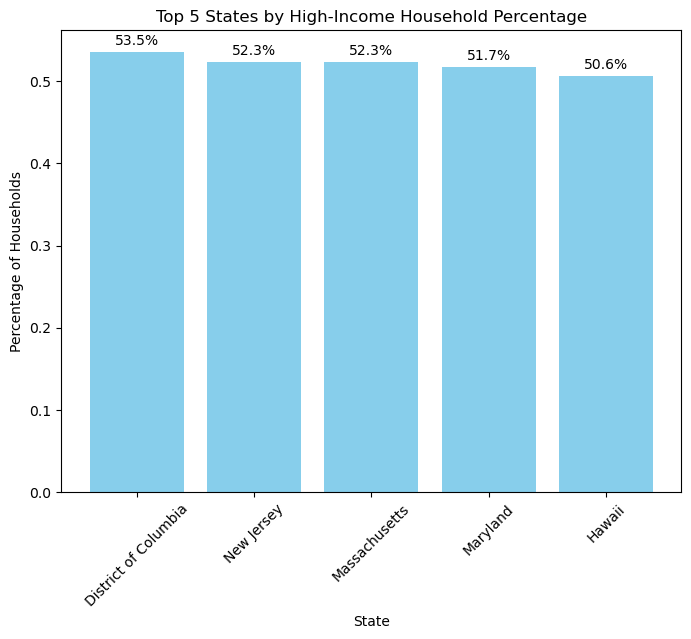

In [38]:
income_plot = income_df.copy()

#drop puerto rice since its technically not a state
income_plot = income_plot[income_plot["state"] != "Puerto Rico"]

low_cols = [
    "Less than $10,000",
    "$10,000 to $14,999",
    "$15,000 to $24,999"
]

mid_cols = [
    "$25,000 to $34,999",
    "$35,000 to $49,999",
    "$50,000 to $74,999",
    "$75,000 to $99,999"
]

high_cols = [
    "$100,000 to $149,999",
    "$150,000 to $199,999",
    "$200,000 or more"
]

income_plot["low_income_share"] = income_plot[low_cols].sum(axis=1)
income_plot["mid_income_share"] = income_plot[mid_cols].sum(axis=1)
income_plot["high_income_share"] = income_plot[high_cols].sum(axis=1)

top5_high = income_plot.sort_values("high_income_share", ascending=False).head(5)

plt.figure(figsize=(8,6))

# vertical bars
plt.bar(top5_high["state"], top5_high["high_income_share"], color='skyblue')

# annotate each bar with percentage
for i, v in enumerate(top5_high["high_income_share"]):
    plt.text(i, v + 0.005, f"{v*100:.1f}%", ha='center', va='bottom')

plt.title("Top 5 States by High-Income Household Percentage")
plt.ylabel("Percentage of Households")
plt.xlabel("State")
plt.xticks(rotation=45)  # rotate x-axis labels for readability

plt.savefig("../FIGURES/Figure_3.jpg", dpi=300) 
plt.show()

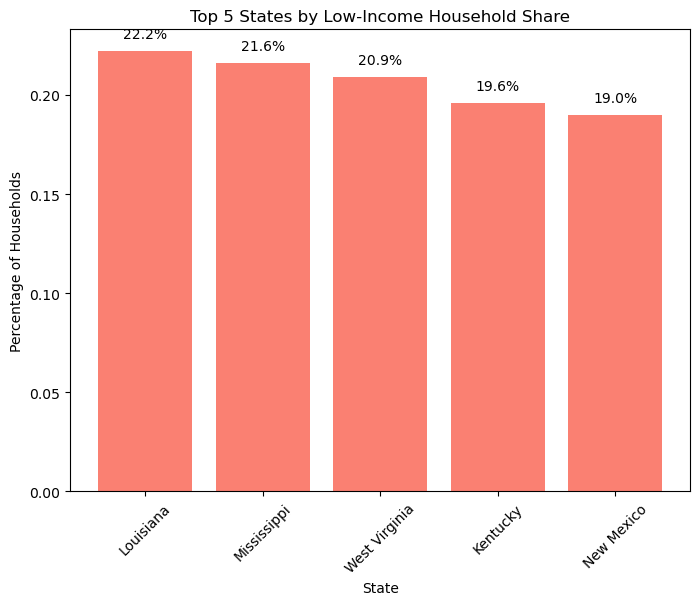

In [39]:
top5_low = income_plot.sort_values("low_income_share", ascending=False).head(5)

plt.figure(figsize=(8,6))

plt.bar(top5_low["state"], top5_low["low_income_share"], color='salmon')

for i, v in enumerate(top5_low["low_income_share"]):
    plt.text(i, v + 0.005, f"{v*100:.1f}%", ha='center', va='bottom')

plt.title("Top 5 States by Low-Income Household Share")
plt.ylabel("Percentage of Households")
plt.xlabel("State")
plt.xticks(rotation=45)

plt.savefig("../FIGURES/Figure_4.jpg", dpi=300) 
plt.show()

## US Employment

In [40]:
employment_plot = employment_df.copy()

#drop puerto rice since its technically not a state
employment_plot = employment_plot[employment_plot["state"] != "Puerto Rico"]

top5_employed = employment_plot.sort_values("In labor force", ascending=False).head(5)

bottom5_employed = employment_plot.sort_values("In labor force", ascending=True).head(5)

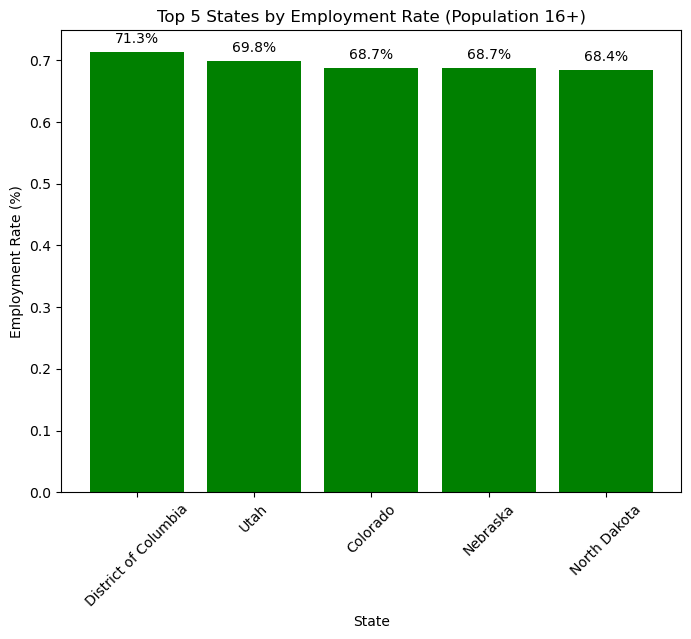

In [41]:
plt.figure(figsize=(8,6))
plt.bar(top5_employed["state"], top5_employed["In labor force"], color='green')

# annotate each bar with %
for i, v in enumerate(top5_employed["In labor force"]):
    plt.text(i, v + 0.01, f"{v*100:.1f}%", ha='center', va='bottom')

plt.title("Top 5 States by Employment Rate (Population 16+)")
plt.ylabel("Employment Rate (%)")
plt.xlabel("State")
plt.xticks(rotation=45)

plt.savefig("../FIGURES/Figure_5.jpg", dpi=300) 
plt.show()

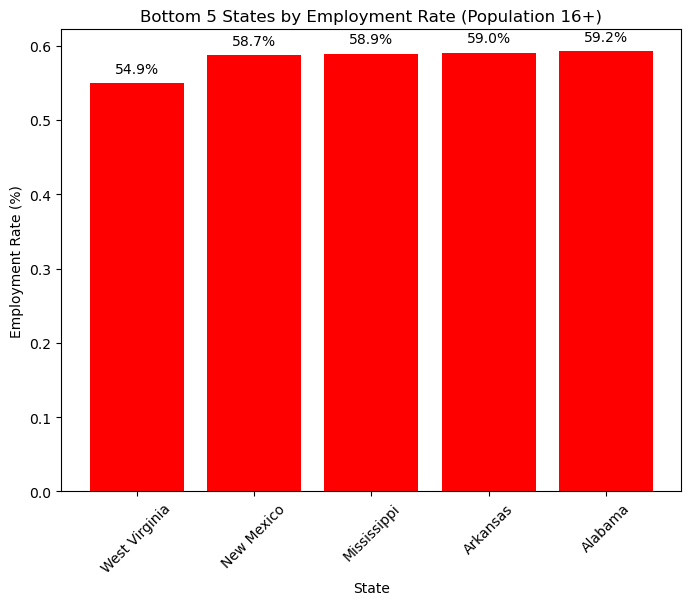

In [42]:
plt.figure(figsize=(8,6))
plt.bar(bottom5_employed["state"], bottom5_employed["In labor force"], color='red')

# annotate each bar with %
for i, v in enumerate(bottom5_employed["In labor force"]):
    plt.text(i, v + 0.01, f"{v*100:.1f}%", ha='center', va='bottom')

plt.title("Bottom 5 States by Employment Rate (Population 16+)")
plt.ylabel("Employment Rate (%)")
plt.xlabel("State")
plt.xticks(rotation=45)

plt.savefig("../FIGURES/Figure_6.jpg", dpi=300) 
plt.show()

## US by County

In [43]:
NM_CO_income_plot = income_df[income_df["state"].isin(["New Mexico", "Colorado"])].copy()

#drop puerto rice since its technically not a state
NM_CO_income_plot = NM_CO_income_plot[NM_CO_income_plot["state"] != "Puerto Rico"]

low_cols = [
    "Less than $10,000",
    "$10,000 to $14,999",
    "$15,000 to $24,999"
]

mid_cols = [
    "$25,000 to $34,999",
    "$35,000 to $49,999",
    "$50,000 to $74,999",
    "$75,000 to $99,999"
]

high_cols = [
    "$100,000 to $149,999",
    "$150,000 to $199,999",
    "$200,000 or more"
]

NM_CO_income_plot["low_income_share"] = NM_CO_income_plot[low_cols].sum(axis=1)
NM_CO_income_plot["mid_income_share"] = NM_CO_income_plot[mid_cols].sum(axis=1)
NM_CO_income_plot["high_income_share"] = NM_CO_income_plot[high_cols].sum(axis=1)

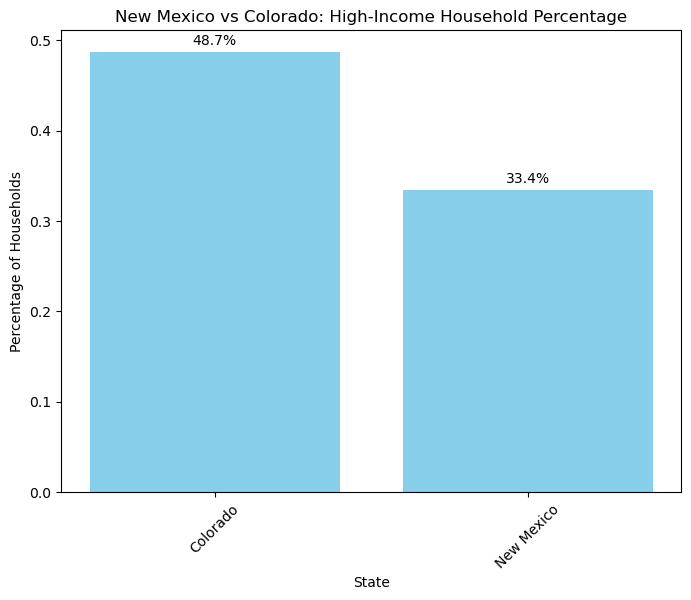

In [44]:
plt.figure(figsize=(8,6))

# vertical bars
plt.bar(NM_CO_income_plot["state"], NM_CO_income_plot["high_income_share"], color='skyblue')

# annotate each bar with percentage
for i, v in enumerate(NM_CO_income_plot["high_income_share"]):
    plt.text(i, v + 0.005, f"{v*100:.1f}%", ha='center', va='bottom')

plt.title("New Mexico vs Colorado: High-Income Household Percentage")
plt.ylabel("Percentage of Households")
plt.xlabel("State")
plt.xticks(rotation=45)  # rotate x-axis labels for readability

plt.savefig("../FIGURES/Figure_7.jpg", dpi=300) 
plt.show()

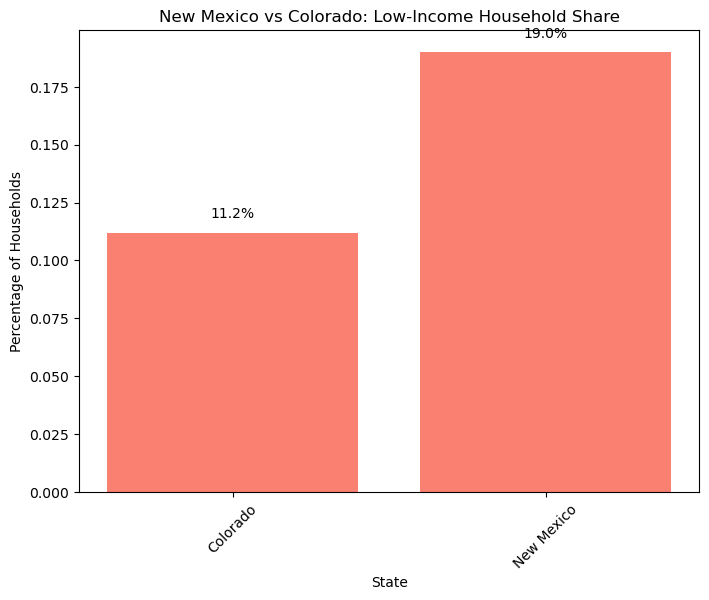

In [45]:
plt.figure(figsize=(8,6))

plt.bar(NM_CO_income_plot["state"], NM_CO_income_plot["low_income_share"], color='salmon')

for i, v in enumerate(NM_CO_income_plot["low_income_share"]):
    plt.text(i, v + 0.005, f"{v*100:.1f}%", ha='center', va='bottom')

plt.title("New Mexico vs Colorado: Low-Income Household Share")
plt.ylabel("Percentage of Households")
plt.xlabel("State")
plt.xticks(rotation=45)

plt.savefig("../FIGURES/Figure_8.jpg", dpi=300) 
plt.show()

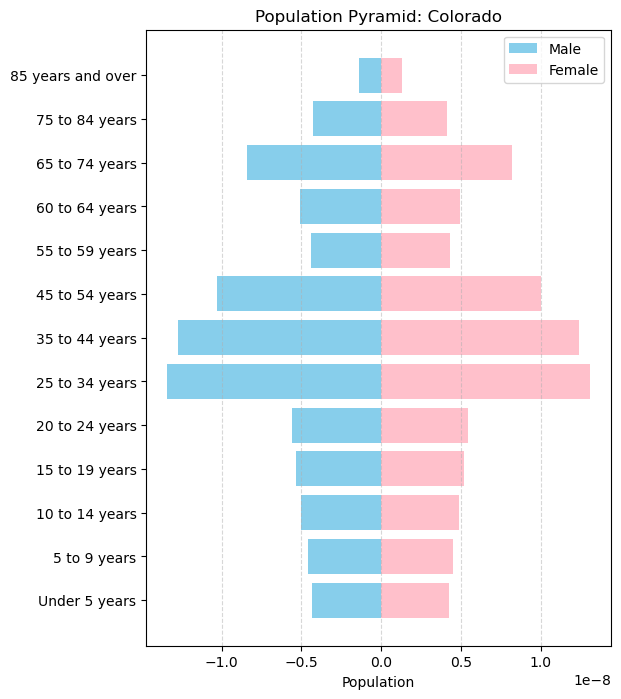

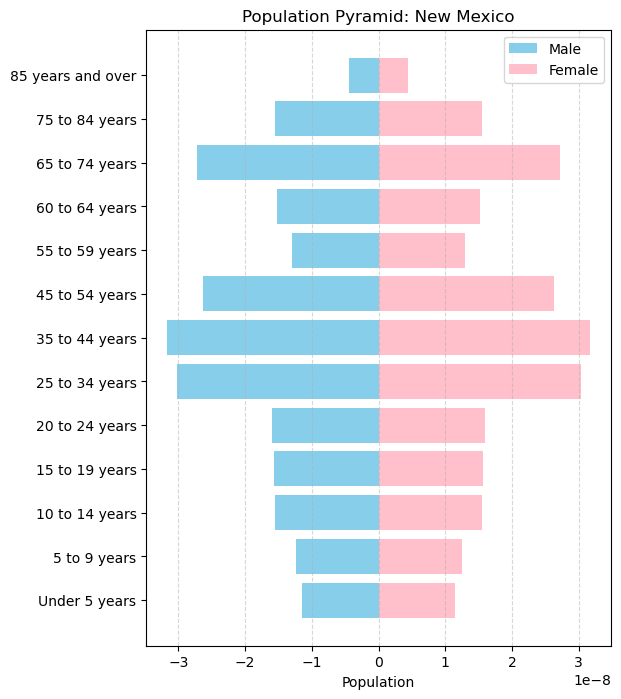

In [46]:
NM_CO_AgeSex_plot = sex_age_df[sex_age_df["state"].isin(["New Mexico", "Colorado"])].copy()

age_cols = [
    "Under 5 years","5 to 9 years","10 to 14 years","15 to 19 years",
    "20 to 24 years","25 to 34 years","35 to 44 years","45 to 54 years",
    "55 to 59 years","60 to 64 years","65 to 74 years","75 to 84 years","85 years and over"
]

for index, row in NM_CO_AgeSex_plot.iterrows():
    state = row["state"]
    
    male = np.array(row[["Male"]])
    female = np.array(row[["Female"]])
    
    # For age groups male/female
    male_age = np.array(row[age_cols]) * (row["Male"] / row["Total population"])
    female_age = np.array(row[age_cols]) * (row["Female"] / row["Total population"])
    
    y = np.arange(len(age_cols))  # age groups
    
    plt.figure(figsize=(6,8))
    
    # plot male left (negative)
    plt.barh(y, -male_age, color='skyblue', label='Male')
    
    # plot female right (positive)
    plt.barh(y, female_age, color='pink', label='Female')
    
    plt.yticks(y, age_cols)
    plt.xlabel("Population")
    plt.title(f"Population Pyramid: {state}")
    plt.legend()
    plt.grid(axis='x', linestyle='--', alpha=0.5)

    plt.savefig("../FIGURES/Figure_9.jpg", dpi=300) 
    plt.show()

# Creating One Table for Census Data

## US

In [47]:
# Merge all created tables into one, merge on state with outer to get all rows
US_census_data_2024 = pd.merge(income_df, education_df, on="state", how="outer")
US_census_data_2024 = pd.merge(US_census_data_2024, employment_df, on="state",how="outer")
US_census_data_2024 = pd.merge(US_census_data_2024, sex_age_df, on="state",how="outer")

# Exclude Puerto Rico
US_census_data_2024 = US_census_data_2024[US_census_data_2024["state"] != "Puerto Rico"]

# Reset Index
US_census_data_2024.reset_index(drop=True)

# View Table
US_census_data_2024

,state,"Less than $10,000","$10,000 to $14,999","$15,000 to $24,999","$25,000 to $34,999","$35,000 to $49,999","$50,000 to $74,999","$75,000 to $99,999","$100,000 to $149,999","$150,000 to $199,999",...,35 to 44 years,45 to 54 years,55 to 59 years,60 to 64 years,65 to 74 years,75 to 84 years,85 years and over,Female,Male,Total population
0,Alabama,0.064,0.047,0.078,0.079,0.112,0.168,0.133,0.160,0.075,...,0.128,0.121,0.060,0.066,0.109,0.058,0.018,0.517,0.483,5157699.0
1,Alaska,0.037,0.020,0.052,0.049,0.088,0.146,0.128,0.206,0.127,...,0.146,0.112,0.049,0.065,0.095,0.041,0.011,0.473,0.527,740133.0
2,Arizona,0.049,0.025,0.056,0.061,0.104,0.164,0.139,0.183,0.098,...,0.129,0.115,0.054,0.062,0.109,0.069,0.018,0.501,0.499,7582384.0
3,Arkansas,0.060,0.046,0.082,0.090,0.128,0.176,0.128,0.158,0.066,...,0.132,0.119,0.056,0.065,0.106,0.059,0.018,0.509,0.491,3088354.0
4,California,0.046,0.030,0.050,0.049,0.079,0.131,0.114,0.179,0.112,...,0.142,0.123,0.059,0.060,0.095,0.052,0.018,0.501,0.499,39431263.0
5,Colorado,0.043,0.023,0.046,0.049,0.078,0.147,0.128,0.190,0.118,...,0.150,0.121,0.052,0.060,0.099,0.050,0.016,0.494,0.506,5957494.0
6,Connecticut,0.048,0.030,0.050,0.050,0.085,0.138,0.117,0.173,0.116,...,0.130,0.120,0.067,0.070,0.111,0.060,0.023,0.509,0.491,3675069.0
7,Delaware,0.049,0.023,0.046,0.050,0.101,0.156,0.144,0.193,0.108,...,0.126,0.111,0.062,0.075,0.129,0.066,0.021,0.518,0.482,1051917.0
8,District of Columbia,0.078,0.035,0.057,0.039,0.053,0.105,0.098,0.168,0.101,...,0.172,0.106,0.047,0.045,0.072,0.043,0.013,0.527,0.473,702250.0
9,Florida,0.052,0.031,0.061,0.067,0.106,0.167,0.132,0.177,0.089,...,0.131,0.121,0.062,0.068,0.118,0.076,0.024,0.508,0.492,23372215.0


In [48]:
# save to a file
US_census_data_2024.to_csv("../DATA/PROCESSED_CENSUS_DATA/US_census_data_2024.csv")

## US by County

In [49]:
# Merge all created tables into one, merge on state with outer to get all rows
county_census_data_2024 = pd.merge(county_income_df, county_education_df, on=["county","state"], how="outer")
county_census_data_2024 = pd.merge(county_census_data_2024, county_employment_df, on=["county","state"],how="outer")
county_census_data_2024 = pd.merge(county_census_data_2024, county_sex_age_df, on=["county","state"],how="outer")

# Exclude Puerto Rico
county_census_data_2024 = county_census_data_2024[county_census_data_2024["state"] != "Puerto Rico"]

# Reset Index
county_census_data_2024.reset_index(drop=True)

# View Table
county_census_data_2024

,state,county,"Less than $10,000","$10,000 to $14,999","$15,000 to $24,999","$25,000 to $34,999","$35,000 to $49,999","$50,000 to $74,999","$75,000 to $99,999","$100,000 to $149,999",...,35 to 44 years,45 to 54 years,55 to 59 years,60 to 64 years,65 to 74 years,75 to 84 years,85 years and over,Female,Male,Total population
0,Idaho,Ada County,0.037,0.030,0.042,0.044,0.086,0.154,0.146,0.204,...,0.144,0.128,0.054,0.061,0.103,0.054,0.018,0.497,0.503,535799.0
1,Colorado,Adams County,0.034,0.022,0.041,0.046,0.073,0.144,0.126,0.226,...,0.158,0.123,0.047,0.055,0.074,0.035,0.010,0.491,0.509,542973.0
2,Pennsylvania,Adams County,0.029,0.013,0.052,0.081,0.096,0.168,0.135,0.210,...,0.111,0.115,0.070,0.072,0.142,0.069,0.023,0.501,0.499,107914.0
3,South Carolina,Aiken County,0.067,0.030,0.051,0.088,0.127,0.157,0.150,0.152,...,0.129,0.112,0.059,0.073,0.126,0.076,0.015,0.513,0.487,179245.0
4,Florida,Alachua County,0.093,0.058,0.088,0.070,0.083,0.165,0.141,0.130,...,0.130,0.092,0.041,0.052,0.095,0.049,0.017,0.523,0.477,291782.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
856,Pennsylvania,York County,0.035,0.020,0.057,0.070,0.110,0.167,0.132,0.206,...,0.135,0.118,0.064,0.071,0.113,0.062,0.021,0.502,0.498,471240.0
857,South Carolina,York County,0.031,0.013,0.049,0.045,0.083,0.159,0.145,0.206,...,0.156,0.132,0.066,0.057,0.100,0.051,0.012,0.513,0.487,303001.0
858,Virginia,York County,0.030,0.003,0.019,0.067,0.060,0.138,0.142,0.197,...,0.136,0.134,0.065,0.057,0.123,0.068,0.012,0.488,0.512,71410.0
859,California,Yuba County,0.023,0.021,0.054,0.078,0.110,0.186,0.127,0.165,...,0.148,0.108,0.050,0.056,0.076,0.041,0.018,0.493,0.507,87469.0


In [50]:
# save to a file
county_census_data_2024.to_csv("../DATA/PROCESSED_CENSUS_DATA/county_census_data_2024.csv")